Problema 1: El departamento de marketing de una empresa registró durante 100 meses la inversión en publicidad digital (en miles de dólares) y las unidades vendidas. Necesitan cuantificar cómo afecta el gasto en publicidad a las ventas para optimizar su presupuesto.

Lo que debe hacer el código:

    Importar y procesar los datos históricos
    Ajustar un modelo de regresión lineal que relacione inversión con ventas
    Evaluar la calidad del modelo mediante MSE y R²
    Visualizar la relación con un gráfico profesional con ejes etiquetados
    Implementar una función para estimar ventas esperadas según posible inversión
    Mostrar la ecuación del modelo en el gráfico

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
df = pd.read_csv('PublicidadVentas.csv')

In [49]:
print(df.head())

   Inversion  Ventas
0        1.2     180
1        1.5     210
2        1.8     250
3        2.0     280
4        2.2     300


In [50]:
X = df[['Inversion']]
y = df['Ventas']

In [51]:
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [52]:
y_pred = modelo.predict(X)

In [53]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

In [54]:
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 38.76425545416376
R2: 0.9997661366378643


In [59]:
m = modelo.coef_[0]
b = modelo.intercept_

print(f"Ecuación: y = {m:.2f}x + {b:.2f}")

Ecuación: y = 80.50x + 112.68


In [55]:
def predecir_ventas(inversion):
    nuevo = pd.DataFrame({'Inversion': [inversion]})
    return modelo.predict(nuevo)[0]

In [56]:
print("Inversion de 50 ventas:", predecir_ventas(50))

Inversion de 50 ventas: 4137.564618767148


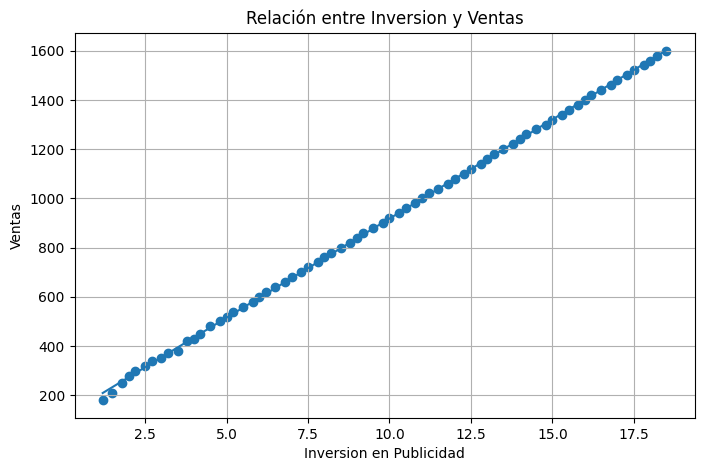

In [57]:
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Relación entre Inversion y Ventas")
plt.xlabel("Inversion en Publicidad")
plt.ylabel("Ventas")
plt.grid()

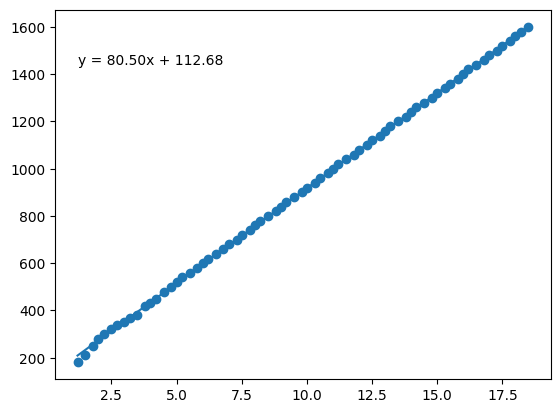

In [58]:
plt.figure()

plt.scatter(X.values, y.values)
plt.plot(X.values, y_pred)

plt.text(
    X.values.min(),
    y.values.max() * 0.9,
    f'y = {m:.2f}x + {b:.2f}'
)

plt.show()